<a href="https://colab.research.google.com/github/MariaMuu/Creatine-Simulation-Analysis/blob/main/EDA_creatine_simulation_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
# Read creatine dataset

df = pd.read_csv('/content/cleaned_synthetic_creatine_study.csv')

In [40]:
# Get basic information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805 entries, 0 to 804
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              805 non-null    float64
 1   sex              805 non-null    object 
 2   creatine_dose_g  805 non-null    int64  
 3   sleep_score      805 non-null    float64
 4   mood_score       805 non-null    float64
 5   cognition_score  805 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 37.9+ KB


### Scatter plot Visualization

In [41]:
print('\n=====================Research Question Analysis=====================\n')
print('Question: Is there a relationship between creatine dosage and sleep quality, mood and cognition performance?')


=====================Research Question Analysis=====================

Question: Is there a relationship between creatine dosage and sleep quality, mood and cognition performance?


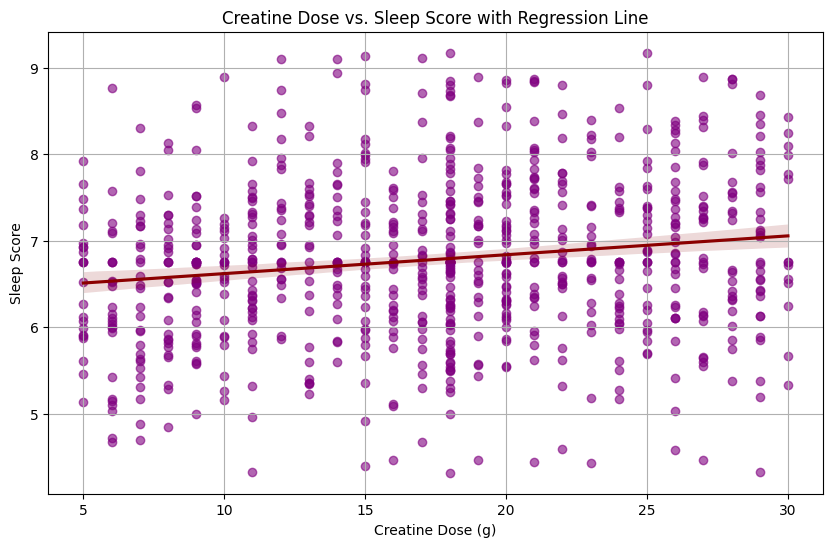

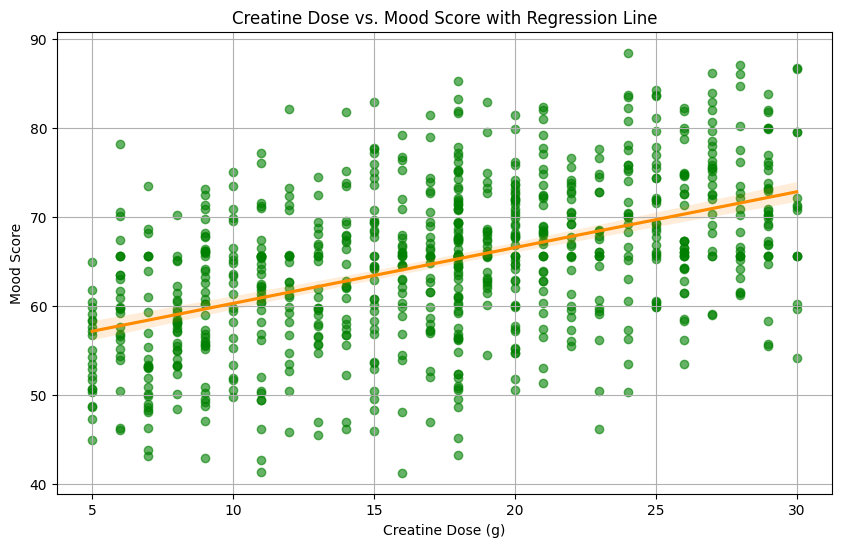

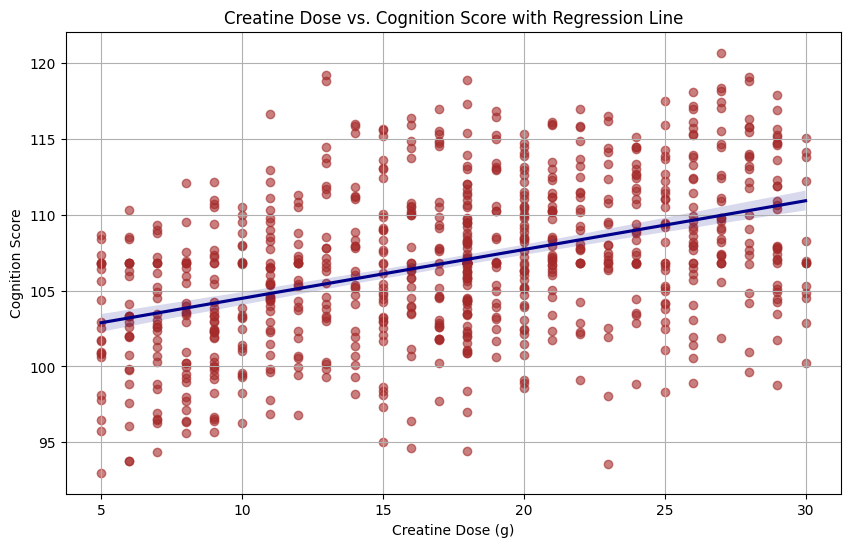

In [42]:
plt.figure(figsize=(10, 6))
sns.regplot(x='creatine_dose_g', y='sleep_score', data=df, scatter_kws={'alpha':0.6}, color='purple', line_kws={'color': 'darkred'})
plt.title('Creatine Dose vs. Sleep Score with Regression Line')
plt.xlabel('Creatine Dose (g)')
plt.ylabel('Sleep Score')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(x='creatine_dose_g', y='mood_score', data=df, scatter_kws={'alpha':0.6}, color='green', line_kws={'color': 'darkorange'})
plt.title('Creatine Dose vs. Mood Score with Regression Line')
plt.xlabel('Creatine Dose (g)')
plt.ylabel('Mood Score')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(x='creatine_dose_g', y='cognition_score', data=df, scatter_kws={'alpha':0.6}, color='brown', line_kws={'color': 'darkblue'})
plt.title('Creatine Dose vs. Cognition Score with Regression Line')
plt.xlabel('Creatine Dose (g)')
plt.ylabel('Cognition Score')
plt.grid(True)
plt.show()

### Correlation Matrix visualization

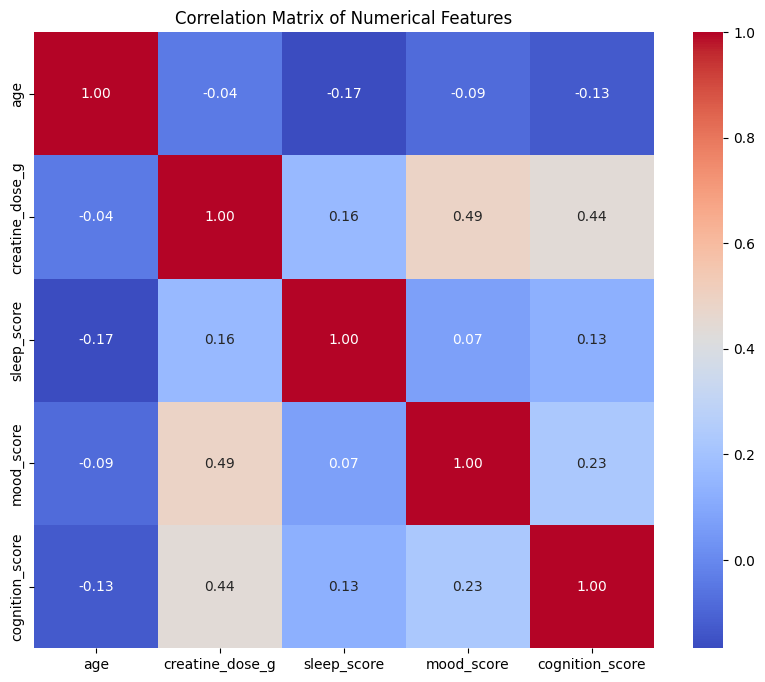

In [43]:
# Select only numerical columns for correlation calculation
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()

# Display the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [57]:
print(f'''Correlation between Creatine dose (g) and Sleep score: {correlation_matrix.loc['creatine_dose_g', 'sleep_score']:.2f}
Correlation between Creatine dose (g) and Cognition score: {correlation_matrix.loc['creatine_dose_g', 'cognition_score']:.2f} (strong positive)
Correlation between Creatine dose (g) and Mood score: {correlation_matrix.loc['creatine_dose_g', 'mood_score']:.2f} (strong positive)
Correlation between Sleep score and Cognition score: {correlation_matrix.loc['sleep_score', 'cognition_score']:.2f}
Correlation between Cognition score and Mood score: {correlation_matrix.loc['cognition_score', 'mood_score']:.2f}''')

Correlation between Creatine dose (g) and Sleep score: 0.16
Correlation between Creatine dose (g) and Cognition score: 0.44 (strong positive)
Correlation between Creatine dose (g) and Mood score: 0.49 (strong positive)
Correlation between Sleep score and Cognition score: 0.13
Correlation between Cognition score and Mood score: 0.23


### Binning and Bar charts visualization

In [53]:
print('\n=====================Research Question Analysis=====================\n')
print("Question: 'How does the average cognition score differ among various creatine dosage categories (low, medium, and high)?")


=====================Research Question Analysis=====================

Question: 'How does the average cognition score differ among various creatine dosage categories (low, medium, and high)?


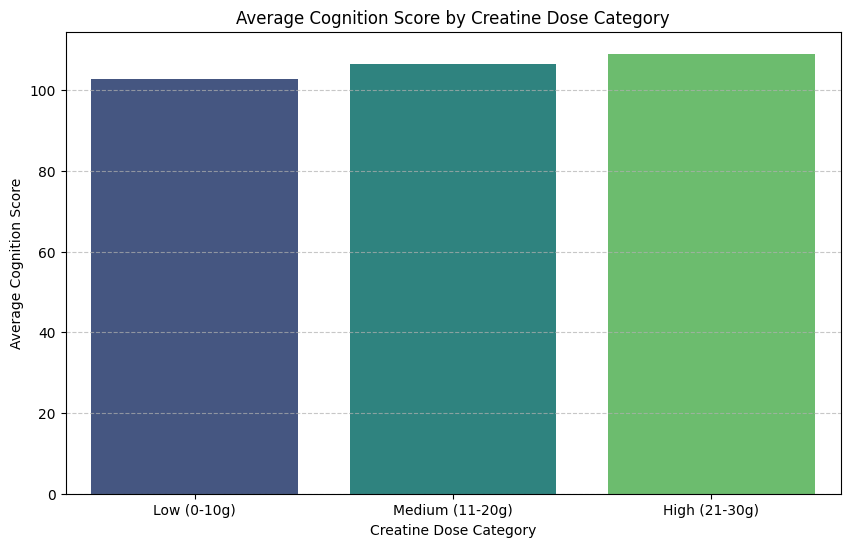

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create categories for creatine dose
df['creatine_dose_category'] = pd.cut(
    df['creatine_dose_g'],
    bins=[0, 10, 20, df['creatine_dose_g'].max() + 1],
    labels=['Low (0-10g)', 'Medium (11-20g)', 'High (21-30g)'],
    right=False
)

# Calculate the average cognition score for each category
average_cognition_by_creatine = df.groupby('creatine_dose_category', observed=False)['cognition_score'].mean().reset_index()

# Create a bar plot to visualize the average cognition score by creatine dose category
plt.figure(figsize=(10, 6))
sns.barplot(
    x='creatine_dose_category',
    y='cognition_score',
    data=average_cognition_by_creatine,
    palette='viridis',
    hue='creatine_dose_category',
    legend=False
)
plt.title('Average Cognition Score by Creatine Dose Category')
plt.xlabel('Creatine Dose Category')
plt.ylabel('Average Cognition Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [58]:
print('''Higher creatine dose categories are associated with higher average cognition scores.
As a result, higher creatine intake leads to higher cognition performance''')

Higher creatine dose categories are associated with higher average cognition scores. 
As a result, higher creatine intake leads to higher cognition performance


### Distribution of Creatine Dosage and scores (Violin plots)

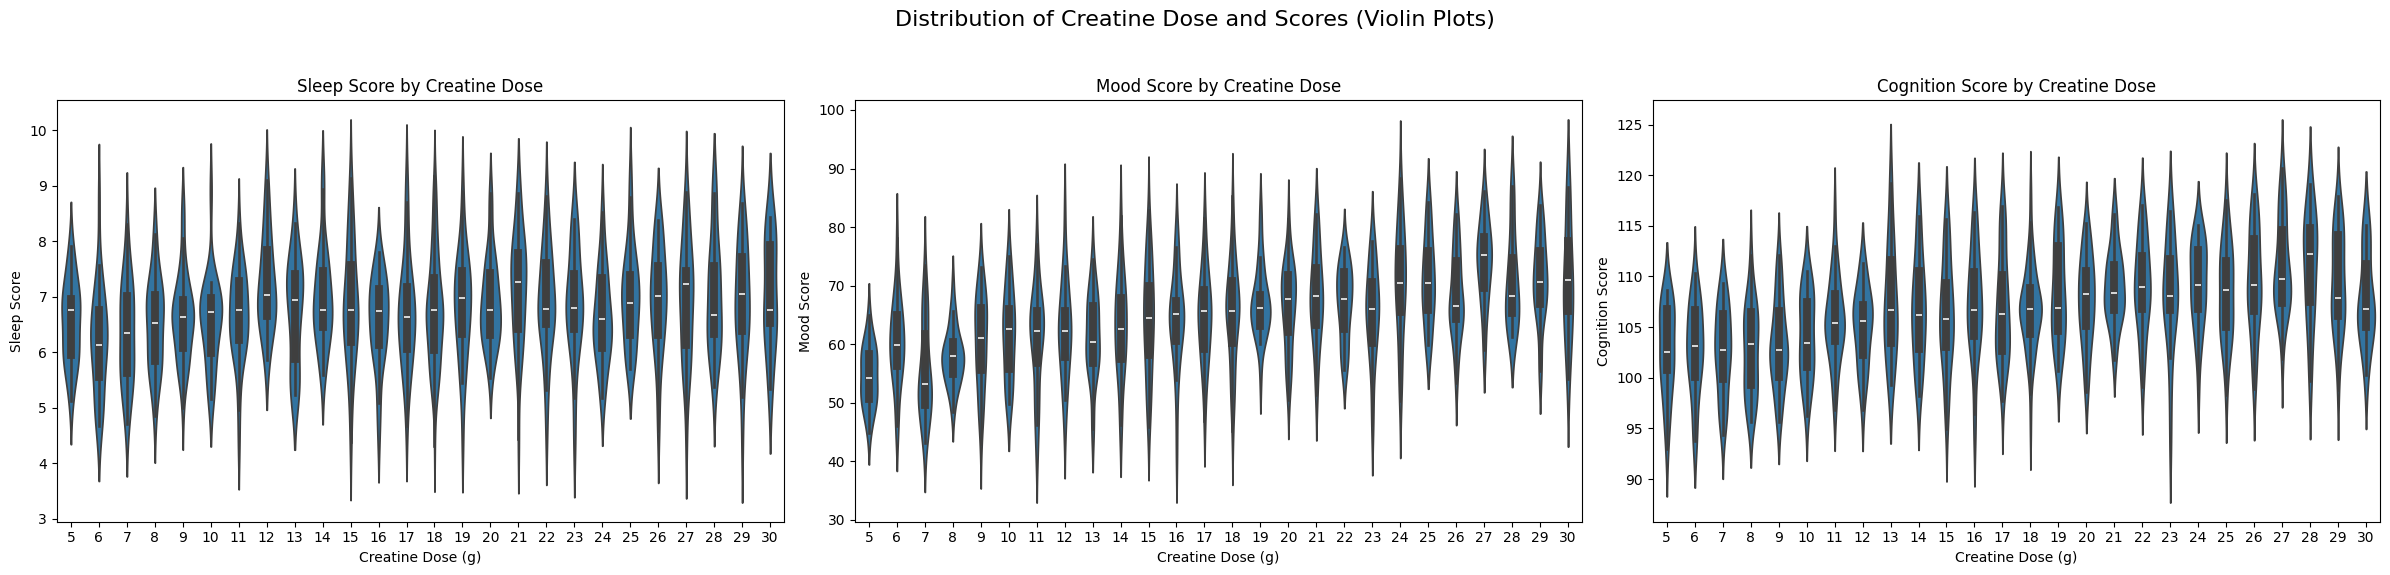

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle('Distribution of Creatine Dose and Scores (Violin Plots)', fontsize=16)

sns.violinplot(x='creatine_dose_g', y='sleep_score', data=df, ax=axes[0])
axes[0].set_title('Sleep Score by Creatine Dose')
axes[0].set_xlabel('Creatine Dose (g)')
axes[0].set_ylabel('Sleep Score')

sns.violinplot(x='creatine_dose_g', y='mood_score', data=df, ax=axes[1])
axes[1].set_title('Mood Score by Creatine Dose')
axes[1].set_xlabel('Creatine Dose (g)')
axes[1].set_ylabel('Mood Score')

sns.violinplot(x='creatine_dose_g', y='cognition_score', data=df, ax=axes[2])
axes[2].set_title('Cognition Score by Creatine Dose')
axes[2].set_xlabel('Creatine Dose (g)')
axes[2].set_ylabel('Cognition Score')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Regression Analysis for creatine dosage and sleep quality, mood and cognition performance

In [49]:
print('\n===================== Creatine Dose vs. Sleep Score Regression =====================')
# Define the regression model formula for sleep score
model_sleep_formula = 'sleep_score ~ creatine_dose_g'

# Fit the regression model for sleep score
model_sleep = smf.ols(model_sleep_formula, data=df).fit()

# Print the summary of the regression results for sleep score
print(model_sleep.summary())

print('\nInterpretation for Creatine Dose vs. Sleep Score:')
creatine_coeff_sleep = model_sleep.params['creatine_dose_g']
p_value_creatine_sleep = model_sleep.pvalues['creatine_dose_g']
r_squared_sleep = model_sleep.rsquared

print(f"  - For every 1-gram increase in creatine dose, the sleep score is estimated to change by {creatine_coeff_sleep:.4f} units.")
if p_value_creatine_sleep < 0.05:
    print(f"  - This relationship is statistically significant (p-value: {p_value_creatine_sleep:.4f}).")
    if creatine_coeff_sleep > 0:
        print("  - A higher creatine dose is associated with a higher sleep score.")
    else:
        print("  - A higher creatine dose is associated with a lower sleep score.")
else:
    print(f"  - This relationship is not statistically significant (p-value: {p_value_creatine_sleep:.4f}).")
print(f"  - The R-squared value ({r_squared_sleep:.4f}) indicates that approximately {r_squared_sleep*100:.2f}% of the variance in sleep score can be explained by creatine dosage alone.")



===================== Creatine Dose vs. Sleep Score Regression =====================
                            OLS Regression Results                            
Dep. Variable:            sleep_score   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     21.86
Date:                Tue, 19 May 2026   Prob (F-statistic):           3.43e-06
Time:                        14:37:14   Log-Likelihood:                -1073.9
No. Observations:                 805   AIC:                             2152.
Df Residuals:                     803   BIC:                             2161.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

In [50]:
import statsmodels.formula.api as smf

print('\n===================== Creatine Dose vs. Mood Score Regression =====================')
# Define the regression model formula for mood score
model_mood_formula = 'mood_score ~ creatine_dose_g'

# Fit the regression model for mood score
model_mood = smf.ols(model_mood_formula, data=df).fit()

# Print the summary of the regression results for mood score
print(model_mood.summary())

print('\nInterpretation for Creatine Dose vs. Mood Score:')
creatine_coeff_mood = model_mood.params['creatine_dose_g']
p_value_creatine_mood = model_mood.pvalues['creatine_dose_g']
r_squared_mood = model_mood.rsquared

print(f"  - For every 1-gram increase in creatine dose, the mood score is estimated to change by {creatine_coeff_mood:.4f} units.")
if p_value_creatine_mood < 0.05:
    print(f"  - This relationship is statistically significant (p-value: {p_value_creatine_mood:.4f}).")
    if creatine_coeff_mood > 0:
        print("  - A higher creatine dose is associated with a higher mood score.")
    else:
        print("  - A higher creatine dose is associated with a lower mood score.")
else:
    print(f"  - This relationship is not statistically significant (p-value: {p_value_creatine_mood:.4f}).")
print(f"  - The R-squared value ({r_squared_mood:.4f}) indicates that approximately {r_squared_mood*100:.2f}% of the variance in mood score can be explained by creatine dosage alone.")


===================== Creatine Dose vs. Mood Score Regression =====================
                            OLS Regression Results                            
Dep. Variable:             mood_score   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     251.4
Date:                Tue, 19 May 2026   Prob (F-statistic):           1.87e-49
Time:                        14:37:14   Log-Likelihood:                -2794.3
No. Observations:                 805   AIC:                             5593.
Df Residuals:                     803   BIC:                             5602.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [51]:
print('\n===================== Creatine Dose vs. Cognition Score Regression =====================')
# Define the regression model formula for cognition score
model_cognition_formula = 'cognition_score ~ creatine_dose_g'

# Fit the regression model for cognition score
model_cognition = smf.ols(model_cognition_formula, data=df).fit()

# Print the summary of the regression results for cognition score
print(model_cognition.summary())

print('\nInterpretation for Creatine Dose vs. cognition Score:')
creatine_coeff_cognition = model_cognition.params['creatine_dose_g']
p_value_creatine_cognition = model_cognition.pvalues['creatine_dose_g']
r_squared_cognition = model_cognition.rsquared

print(f"  - For every 1-gram increase in creatine dose, the cognition score is estimated to change by {creatine_coeff_cognition:.4f} units.")
if p_value_creatine_cognition < 0.05:
    print(f"  - This relationship is statistically significant (p-value: {p_value_creatine_cognition:.4f}).")
    if creatine_coeff_cognition > 0:
        print("  - A higher creatine dose is associated with a higher cognition score.")
    else:
        print("  - A higher creatine dose is associated with a lower cognition score.")
else:
    print(f"  - This relationship is not statistically significant (p-value: {p_value_creatine_cognition:.4f}).")
print(f"  - The R-squared value ({r_squared_cognition:.4f}) indicates that approximately {r_squared_cognition*100:.2f}% of the variance in cognition score can be explained by creatine dosage alone.")



===================== Creatine Dose vs. Cognition Score Regression =====================
                            OLS Regression Results                            
Dep. Variable:        cognition_score   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     187.4
Date:                Tue, 19 May 2026   Prob (F-statistic):           1.68e-38
Time:                        14:37:14   Log-Likelihood:                -2375.9
No. Observations:                 805   AIC:                             4756.
Df Residuals:                     803   BIC:                             4765.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

In [56]:
print('''===================== Conclusions from Analysis =====================
Based on the various analyses conducted in this notebook, here are the key conclusions regarding creatine dosage and its relationship with sleep, mood, and cognition scores:

Key Conclusions:

1.  Creatine Dosage and Cognition Score:
    *   There is a strong positive correlation (0.44) between creatine dosage and cognition score.
    *   Regression analysis shows a statistically significant positive relationship. For every 1-gram increase in creatine dose, the cognition score is estimated to increase by approximately 0.3220 units (p-value: 0.0000).
    *   Creatine dosage explains about 18.93% of the variance in cognition score (R-squared).
    *   Visualizations (bar plots and violin plots) consistently demonstrate that higher creatine dosages are associated with higher average cognition scores.

2.  Creatine Dosage and Mood Score:
    *   There is a strong positive correlation (0.49) between creatine dosage and mood score.
    *   Regression analysis shows a statistically significant positive relationship. For every 1-gram increase in creatine dose, the mood score is estimated to increase by approximately 0.6270 units (p-value: 0.0000).
    *   Creatine dosage explains about 23.84% of the variance in mood score (R-squared), suggesting a more pronounced effect than on cognition in this simple linear model.
    *   Violin plots visually support this positive trend.

3.  Creatine Dosage and Sleep Score:
    *   There is a weak positive correlation (0.16) between creatine dosage and sleep score.
    *   Regression analysis shows a statistically significant positive relationship, but the effect size is very small. For every 1-gram increase in creatine dose, the sleep score is estimated to increase by approximately 0.0218 units (p-value: 0.0000).
    *   Creatine dosage explains only about 2.65% of the variance in sleep score (R-squared), indicating a very minor influence.

4.  Other Relationships:
    *   Sleep Score and Cognition Score: There is a weak positive correlation (0.13).
    *   Cognition Score and Mood Score: There is a moderate positive correlation (0.23).

Overall Summary:
Creatine dosage appears to have a statistically significant positive association with cognition, mood, and sleep scores. The impact is most substantial and consistent for mood and cognition, where higher doses are linked to notably better scores, and creatine dosage explains a meaningful portion of their variance. While statistically significant, the effect on sleep score is considerably weaker and explains very little of its variance.''')

===================== Conclusions from Analysis =====================
Based on the various analyses conducted in this notebook, here are the key conclusions regarding creatine dosage and its relationship with sleep, mood, and cognition scores:

Key Conclusions:

1.  Creatine Dosage and Cognition Score:
    *   There is a strong positive correlation (0.44) between creatine dosage and cognition score.
    *   Regression analysis shows a statistically significant positive relationship. For every 1-gram increase in creatine dose, the cognition score is estimated to increase by approximately 0.3220 units (p-value: 0.0000).
    *   Creatine dosage explains about 18.93% of the variance in cognition score (R-squared).
    *   Visualizations (bar plots and violin plots) consistently demonstrate that higher creatine dosages are associated with higher average cognition scores.

2.  Creatine Dosage and Mood Score:
    *   There is a strong positive correlation (0.49) between creatine dosage and mo